In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Uber Request Data.csv")

In [3]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [4]:
df.shape

(6745, 6)

In [5]:
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [7]:
df['Request timestamp'] = pd.to_datetime(
    df['Request timestamp'],
    format='mixed',
    dayfirst=True
)

df['Drop timestamp'] = pd.to_datetime(
    df['Drop timestamp'],
    format='mixed',
    dayfirst=True
)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   object        
 4   Request timestamp  6745 non-null   datetime64[ns]
 5   Drop timestamp     2831 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 316.3+ KB


In [9]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [10]:
df[df['Driver id'].isnull()].head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
4095,1362,City,NaN,No Cars Available,2016-07-11 00:02:00,NaT
4096,1364,City,NaN,No Cars Available,2016-07-11 00:06:00,NaT
4097,1366,City,NaN,No Cars Available,2016-07-11 00:09:00,NaT
4098,2,Airport,NaN,No Cars Available,2016-07-11 00:23:00,NaT
4099,7,Airport,NaN,No Cars Available,2016-07-11 00:30:00,NaT


In [11]:
df['Request Hour'] = df['Request timestamp'].dt.hour

In [12]:
df[['Request timestamp', 'Request Hour']].head()

,Request timestamp,Request Hour
0,2016-07-11 11:51:00,11
1,2016-07-11 17:57:00,17
2,2016-07-12 09:17:00,9
3,2016-07-12 21:08:00,21
4,2016-07-13 08:33:16,8


In [13]:
def get_time_slot(hour):
    if 0 <= hour < 5:
        return 'Late Night'
    elif 5 <= hour < 9:
        return 'Early Morning'
    elif 9 <= hour < 13:
        return 'Morning'
    elif 13 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

In [14]:
df['Time Slot'] = df['Request Hour'].apply(get_time_slot)

In [15]:
df['Status'].value_counts()

Status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

In [16]:
import plotly.express as px

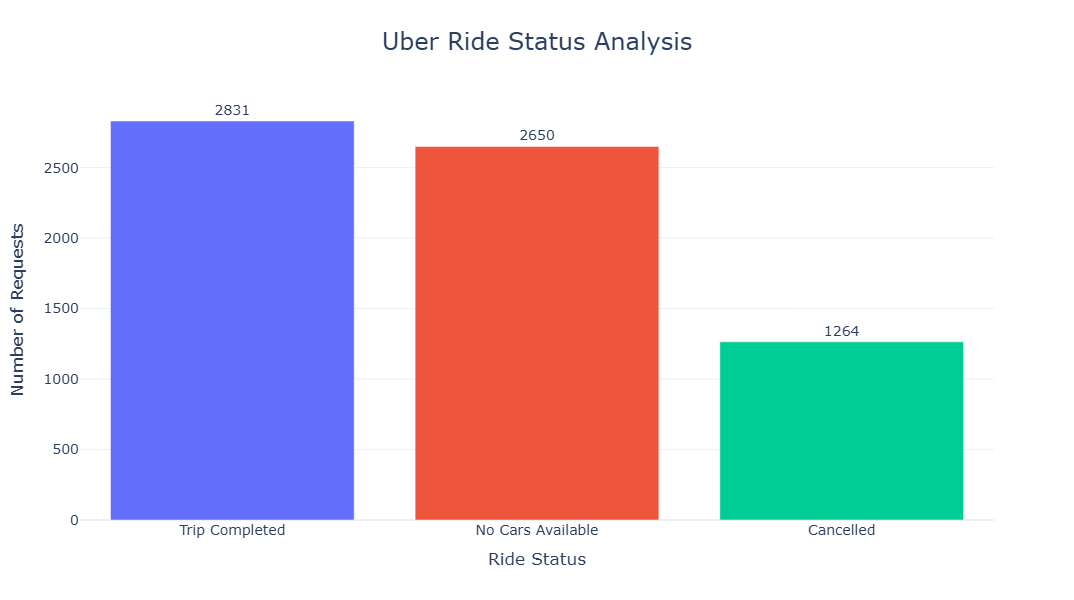

In [17]:

# Count status values
status_count = df['Status'].value_counts().reset_index()
status_count.columns = ['Status', 'Count']

# Create chart
fig = px.bar(
    status_count,
    x='Status',
    y='Count',
    text='Count',
    color='Status',
    title='Uber Ride Status Analysis'
)

# Professional formatting
fig.update_layout(
    template='plotly_white',
    title={
        'text': 'Uber Ride Status Analysis',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24}
    },
    xaxis_title='Ride Status',
    yaxis_title='Number of Requests',
    font=dict(size=14),
    width=1000,
    height=600,
    showlegend=False
)

# Display values on bars
fig.update_traces(
    textposition='outside'
)
fig.show()

In [18]:
import plotly.express as px
import plotly.graph_objects as go

px.defaults.template = "plotly_white"

In [19]:
hourly_requests = df.groupby('Request Hour').size().reset_index(name='Requests')

fig = px.line(
    hourly_requests,
    x='Request Hour',
    y='Requests',
    markers=True,
    title='Hourly Ride Demand Analysis'
)

fig.update_layout(
    title_x=0.5,
    width=1100,
    height=600,
    xaxis_title='Hour of Day',
    yaxis_title='Number of Requests'
)

fig.show()

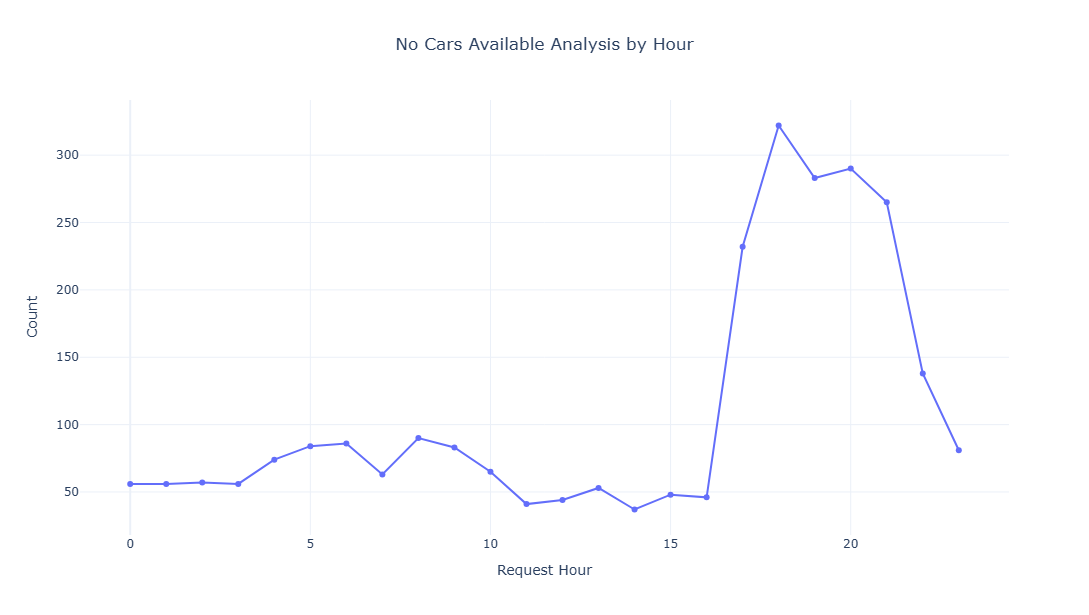

In [20]:
no_car = df[df['Status'] == 'No Cars Available']

hourly_no_car = no_car.groupby('Request Hour').size().reset_index(name='Count')

fig = px.line(
    hourly_no_car,
    x='Request Hour',
    y='Count',
    markers=True,
    title='No Cars Available Analysis by Hour'
)

fig.update_layout(
    title_x=0.5,
    width=1100,
    height=600
)

fig.show()

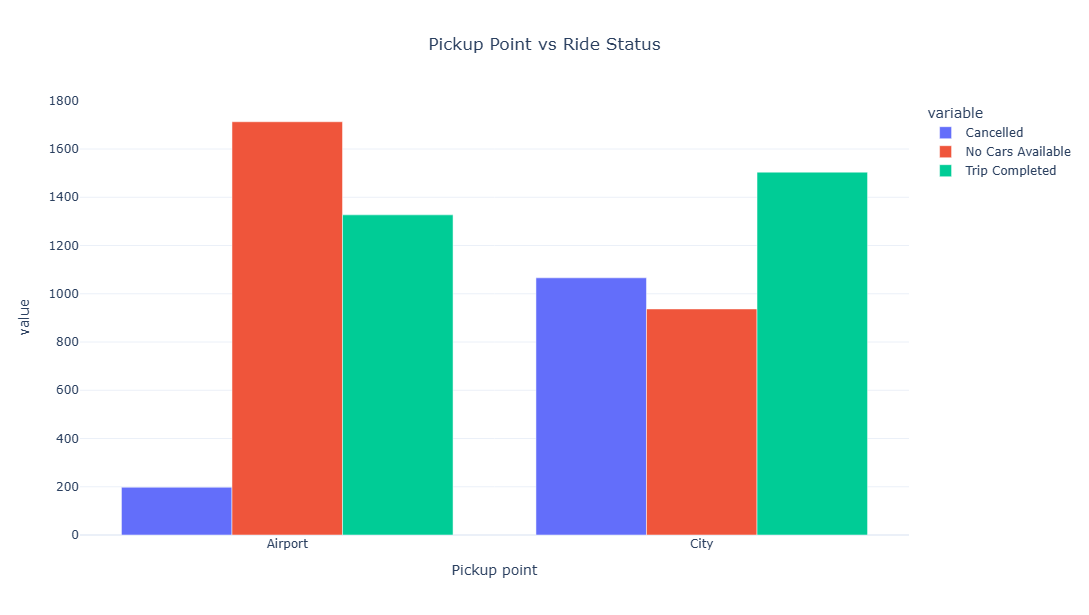

In [21]:
pickup_status = pd.crosstab(
    df['Pickup point'],
    df['Status']
).reset_index()

fig = px.bar(
    pickup_status,
    x='Pickup point',
    y=['Cancelled', 'No Cars Available', 'Trip Completed'],
    barmode='group',
    title='Pickup Point vs Ride Status'
)

fig.update_layout(
    title_x=0.5,
    width=1100,
    height=600
)

fig.show()

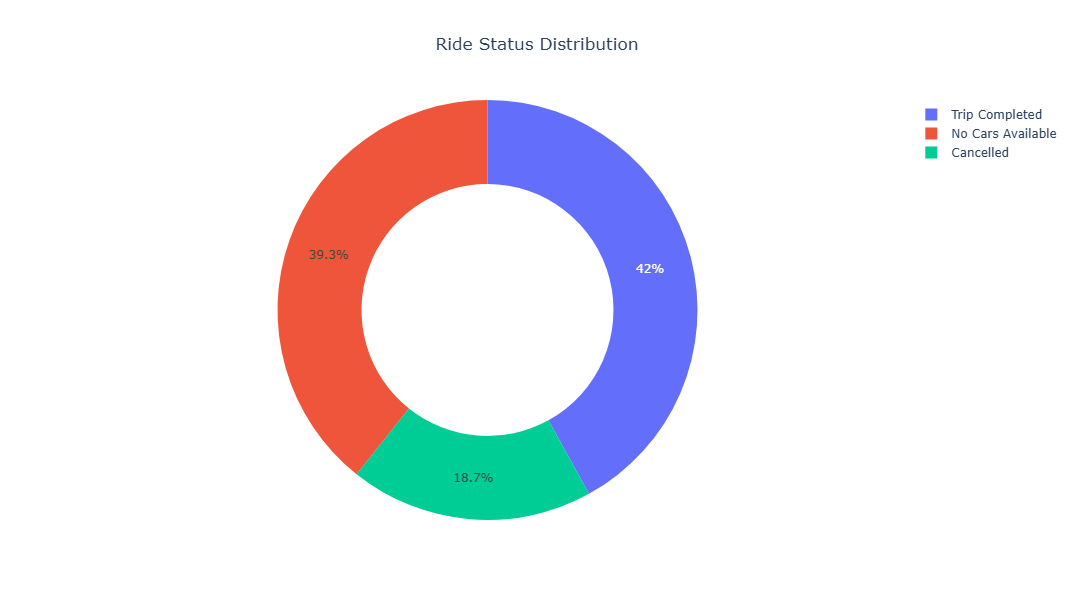

In [22]:
status_count = df['Status'].value_counts().reset_index()
status_count.columns = ['Status', 'Count']

fig = px.pie(
    status_count,
    names='Status',
    values='Count',
    hole=0.6,
    title='Ride Status Distribution'
)

fig.update_layout(
    title_x=0.5,
    width=800,
    height=600
)

fig.show()

In [23]:
df.to_csv("Uber_Cleaned_Data.csv", index=False)

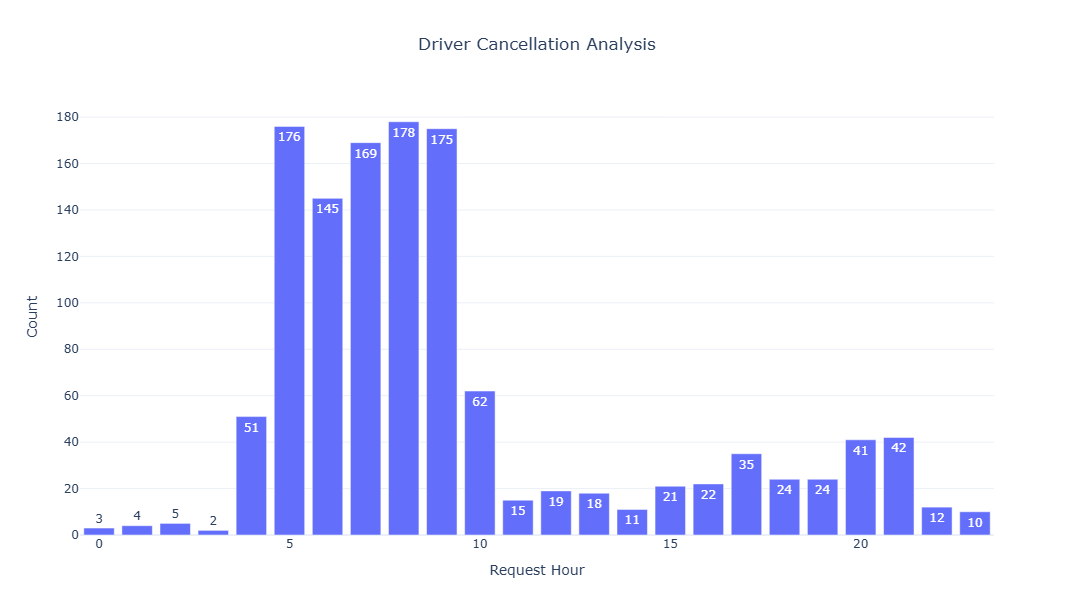

In [24]:
cancelled = df[df['Status'] == 'Cancelled']

cancel_hour = cancelled.groupby('Request Hour').size().reset_index(name='Count')

fig = px.bar(
    cancel_hour,
    x='Request Hour',
    y='Count',
    text='Count',
    title='Driver Cancellation Analysis'
)

fig.update_layout(
    title_x=0.5,
    width=1100,
    height=600
)

fig.show()